<a href="https://colab.research.google.com/github/sonjaove/progg-and-DS-from-IITM/blob/ML/Copy_of_DL_23f2003037_notebook_t12026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mounting the data from kaggle everytime

In [1]:
import json

kaggle_dict = {
    "username": "vedanshivaghela",
    "key": "aa0ca699ba35b158e2dff13dc909bc6a"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

# Step 2: Move it to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Step 3: Set permissions
!chmod 600 ~/.kaggle/kaggle.json
import subprocess

!kaggle competitions download -c jan-2026-dl-gen-ai-project
subprocess.run(["unzip", "-q", "jan-2026-dl-gen-ai-project.zip"], check=True)
!rm jan-2026-dl-gen-ai-project.zip
print("Done!")

100% 16.1G/16.1G [01:26<00:00, 199MB/s]

Done!


## Initializing WandB and hugging face

In [2]:
import os
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("huggingface_token"))

os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
os.environ["WANDB_ENTITY"] = "23f2003037-indian-institute-of-technology-madras"
os.environ["WANDB_PROJECT"] = "23f2003037-t12026"

# ✅ Passing Criteria

1. **Build & Compare Models**
   - 3 models (1 scratch, 1 pretrained, 1 any)
   - Track ≥3 runs in W&B with Accuracy & F1

2. **Show Genuine Work**
   - Commits over 3+ weeks
   - Explain code + write small snippet in viva

3. **Meet Performance**
   - Kaggle score ≥ 0.80

## Data visulization and EDA

### Plots chosen for visualization:
1. **Waveform** - shows raw audio amplitude over time.  
2. **Mel Spectrogram** - represents frequency content aligned with human hearing.  
3. **Spectrogram** - displays frequency vs time with intensity.  
4. **MFCC** - captures compact features for timbre and audio characteristics, roughly speaking, the texture of the sound rather than pitch or rhythm
5. **Box plot** - for seeing different outliers in different genre stems

- **SR = 24000** – standard rate for MERT

In [4]:
import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt

MASHUPS_DIR = "/content/messy_mashup/mashups"
STEMS_DIR   = "/content/messy_mashup/genres_stems"
SR = 24000

records = []

# Genre Stems
for genre in sorted(os.listdir(STEMS_DIR)):
    genre_path = os.path.join(STEMS_DIR, genre)
    if not os.path.isdir(genre_path):
        continue
    for track_folder in os.listdir(genre_path):
        track_path = os.path.join(genre_path, track_folder)
        if not os.path.isdir(track_path):
            continue
        for f in os.listdir(track_path):
            if not f.endswith(".wav"):
                continue
            path = os.path.join(track_path, f)
            try:
                y, sr = librosa.load(path, sr=None)
                records.append({
                    "source":       "stem",
                    "genre":        genre,
                    "track":        track_folder,
                    "file":         f,
                    "path":         path,
                    "duration":     librosa.get_duration(y=y, sr=sr),
                    "rms":          float(librosa.feature.rms(y=y).mean()),
                    "zcr":          float(librosa.feature.zero_crossing_rate(y).mean()),
                    "is_clipped":   bool(np.any(np.abs(y) >= 0.999)),
                    "is_silent":    bool(librosa.feature.rms(y=y).mean() < 1e-4),
                    "actual_sr":    sr,
                    "num_samples":  len(y),
                })
            except Exception as e:
                records.append({
                    "source": "stem", "genre": genre, "track": track_folder,
                    "file": f, "path": path,
                    "duration": None, "rms": None, "zcr": None,
                    "is_clipped": None, "is_silent": None,
                    "actual_sr": None, "num_samples": None,
                    "error": str(e)
                })

# Mashups
for f in sorted(os.listdir(MASHUPS_DIR)):
    if not f.endswith(".wav"):
        continue
    path = os.path.join(MASHUPS_DIR, f)
    try:
        y, sr = librosa.load(path, sr=None)
        records.append({
            "source":       "mashup",
            "genre":        "mashup",
            "track":        None,
            "file":         f,
            "path":         path,
            "duration":     librosa.get_duration(y=y, sr=sr),
            "rms":          float(librosa.feature.rms(y=y).mean()),
            "zcr":          float(librosa.feature.zero_crossing_rate(y).mean()),
            "is_clipped":   bool(np.any(np.abs(y) >= 0.999)),
            "is_silent":    bool(librosa.feature.rms(y=y).mean() < 1e-4),
            "actual_sr":    sr,
            "num_samples":  len(y),
        })
    except Exception as e:
        records.append({
            "source": "mashup", "genre": "mashup", "track": None,
            "file": f, "path": path,
            "duration": None, "rms": None, "zcr": None,
            "is_clipped": None, "is_silent": None,
            "actual_sr": None, "num_samples": None,
            "error": str(e)
        })

df = pd.DataFrame(records)
print(f"Total files scanned: {len(df)}")

ESC50_DIR  = "/content/messy_mashup/ESC-50-master/audio"
ESC50_META = "/content/messy_mashup/ESC-50-master/meta/esc50.csv"

esc_meta = pd.read_csv(ESC50_META)

for _, row in esc_meta.iterrows():
    path = os.path.join(ESC50_DIR, row['filename'])
    if not os.path.exists(path):
        continue
    try:
        y, sr = librosa.load(path, sr=None)
        records.append({
            "source":       "noise",
            "genre":        row['category'],   # e.g. "dog", "rain", "chainsaw"
            "track":        row['fold'],        # ESC-50 fold number
            "file":         row['filename'],
            "path":         path,
            "duration":     librosa.get_duration(y=y, sr=sr),
            "rms":          float(librosa.feature.rms(y=y).mean()),
            "zcr":          float(librosa.feature.zero_crossing_rate(y).mean()),
            "is_clipped":   bool(np.any(np.abs(y) >= 0.999)),
            "is_silent":    bool(librosa.feature.rms(y=y).mean() < 1e-4),
            "actual_sr":    sr,
            "num_samples":  len(y),
        })
    except Exception as e:
        records.append({
            "source": "noise", "genre": row['category'], "track": row['fold'],
            "file": row['filename'], "path": path,
            "duration": None, "rms": None, "zcr": None,
            "is_clipped": None, "is_silent": None,
            "actual_sr": None, "num_samples": None,
            "error": str(e)
        })

df = pd.DataFrame(records)
print(f"Total files scanned: {len(df)}")
print(f"  Stems:   {len(df[df.source == 'stem'])}")
print(f"  Mashups: {len(df[df.source == 'mashup'])}")
print(f"  Noise:   {len(df[df.source == 'noise'])}")

Total files scanned: 7020
Total files scanned: 9020
  Stems:   4000
  Mashups: 3020
  Noise:   2000


## ESC-50 Noise Analysis

In [5]:
def plot_audio(file_path, label):
    y, sr = librosa.load(file_path, sr=SR)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(label, fontsize=13)
    librosa.display.waveshow(y, sr=sr, ax=axes[0, 0])
    axes[0, 0].set_title("Waveform")
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', ax=axes[0, 1])
    axes[0, 1].set_title("Spectrogram")
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1, 0])
    axes[1, 0].set_title("Mel Spectrogram")
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    librosa.display.specshow(mfcc, x_axis='time', ax=axes[1, 1])
    axes[1, 1].set_title("MFCC")
    plt.tight_layout()
    plt.show()
    plt.close()

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A

Total noise clips: 2000
Unique categories: 50
category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40


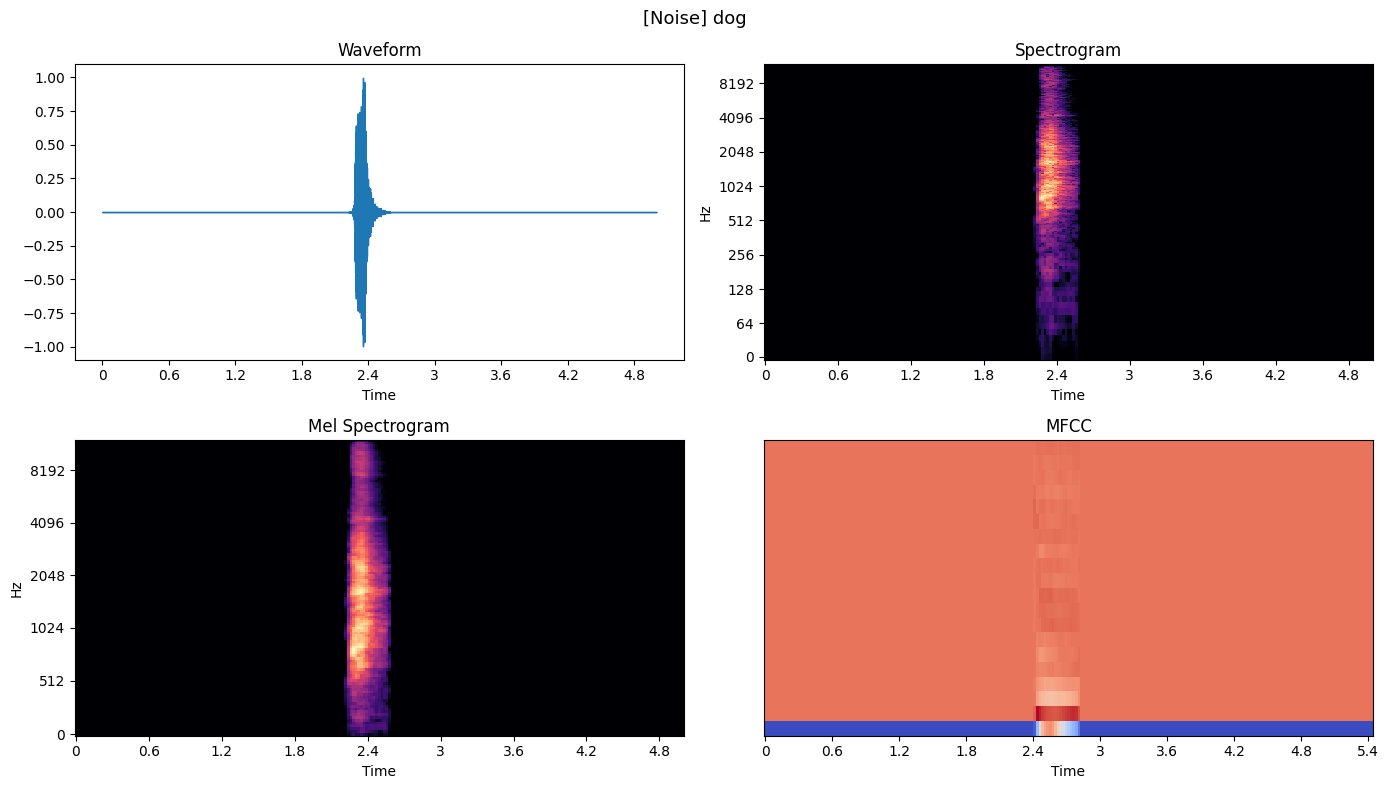

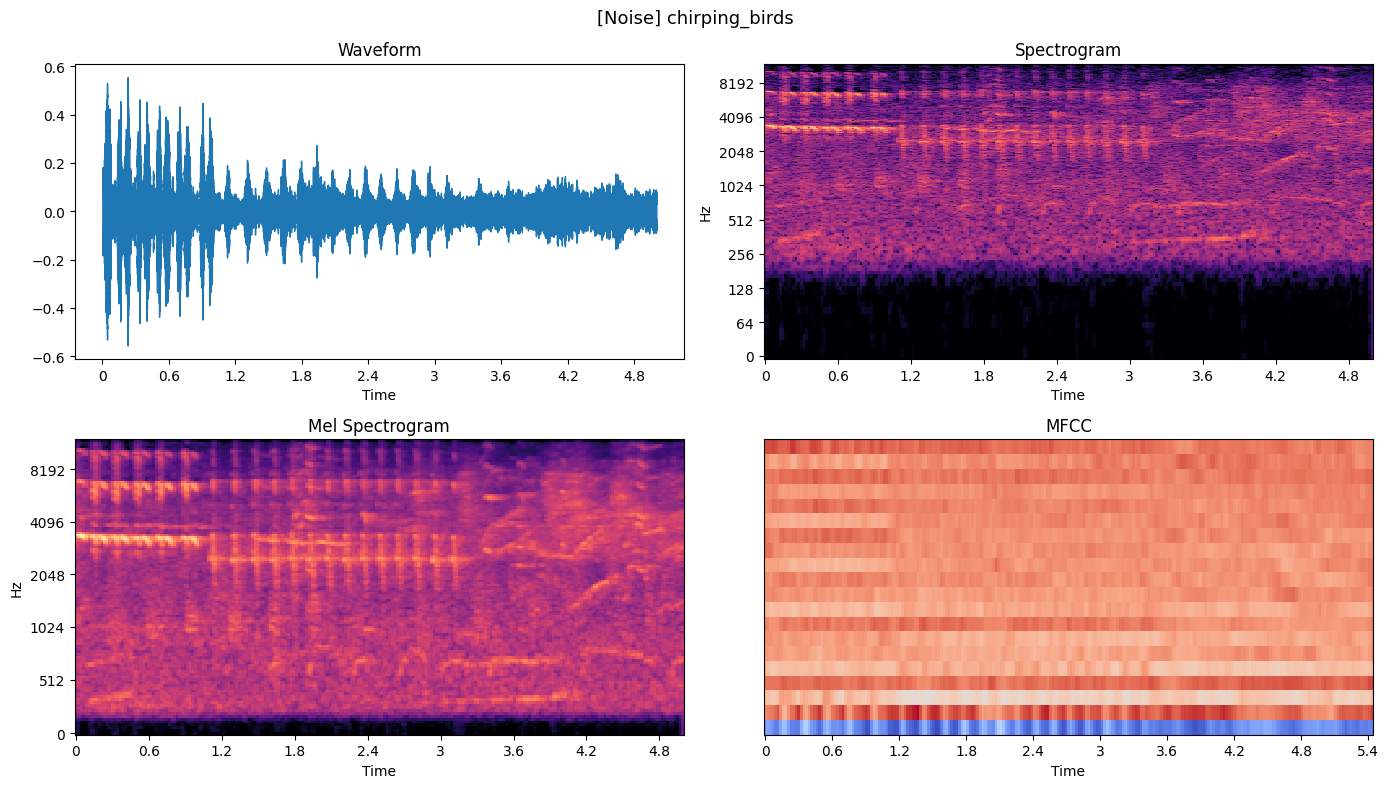

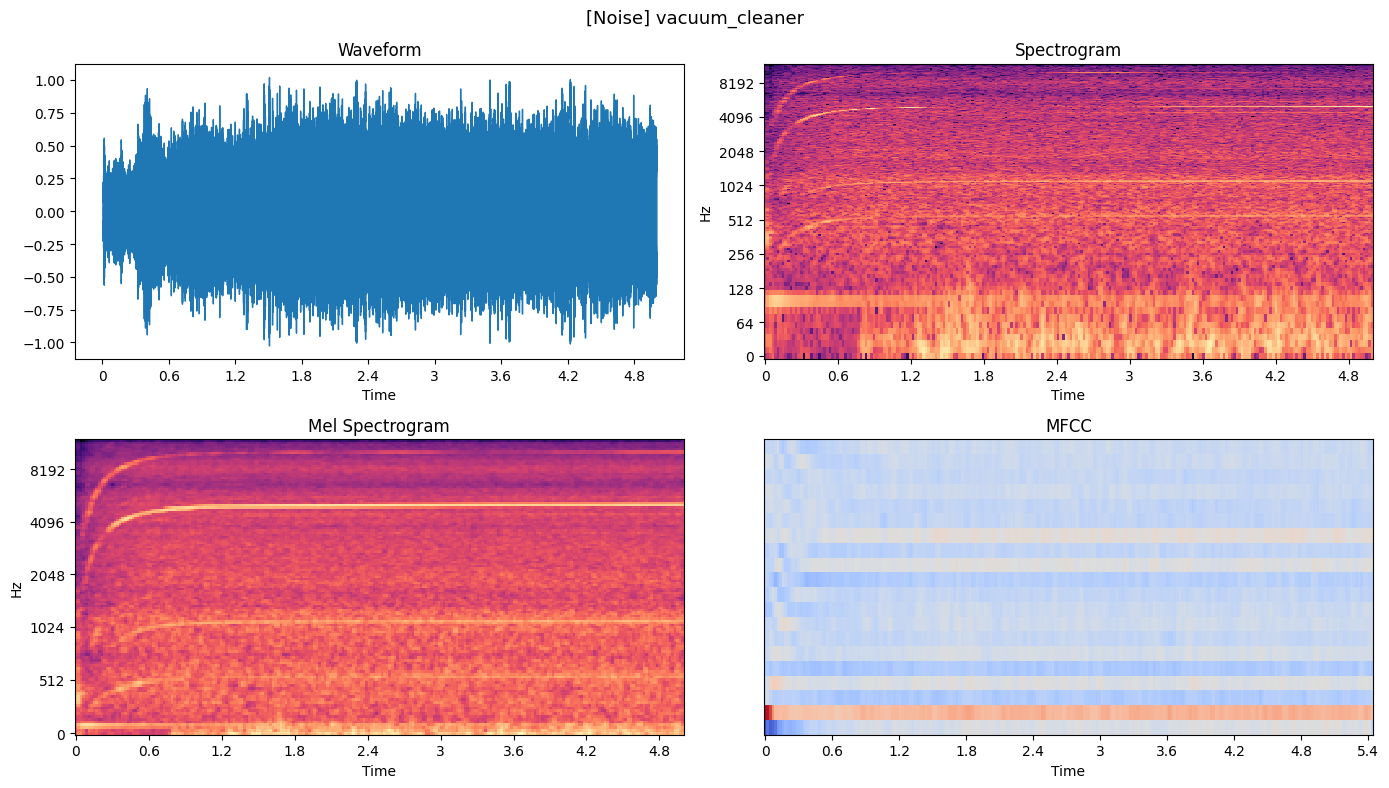

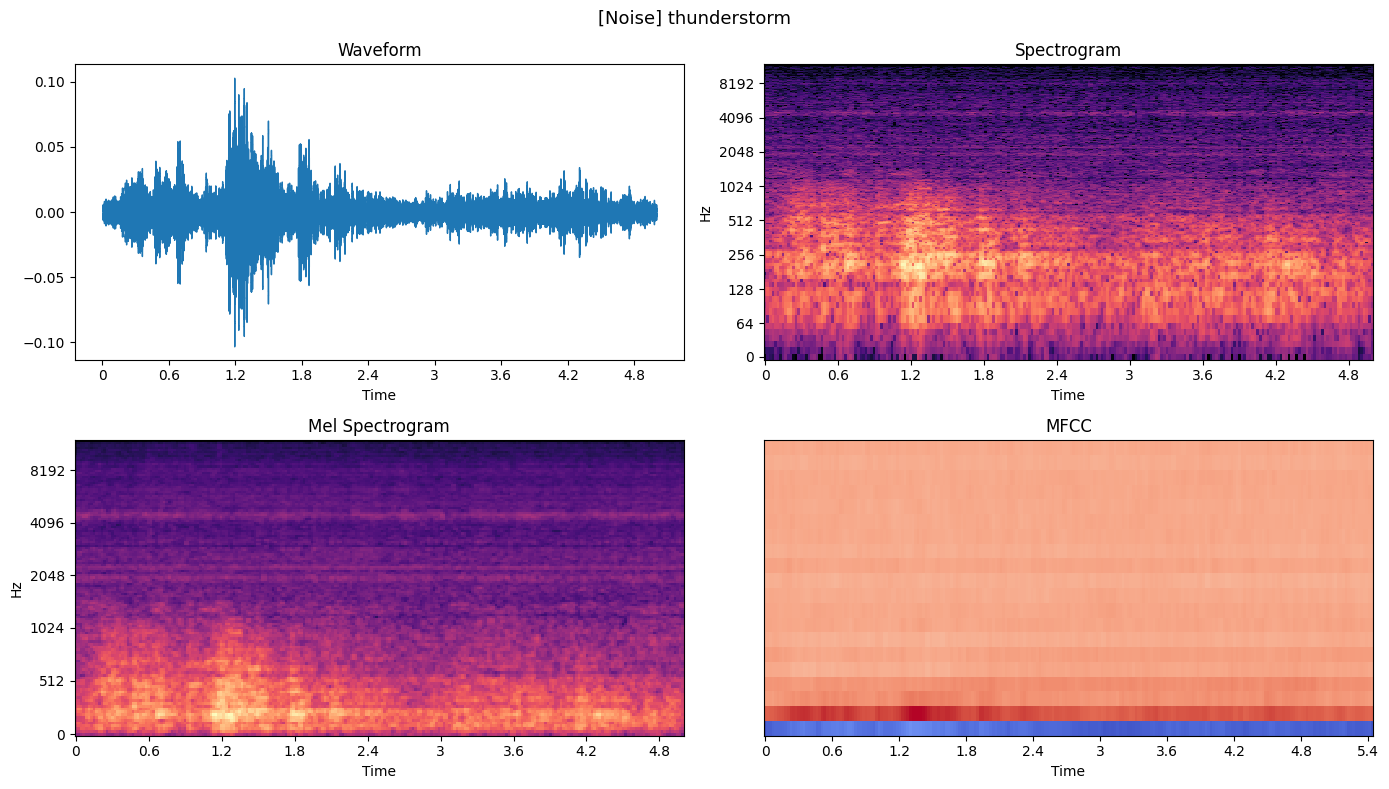

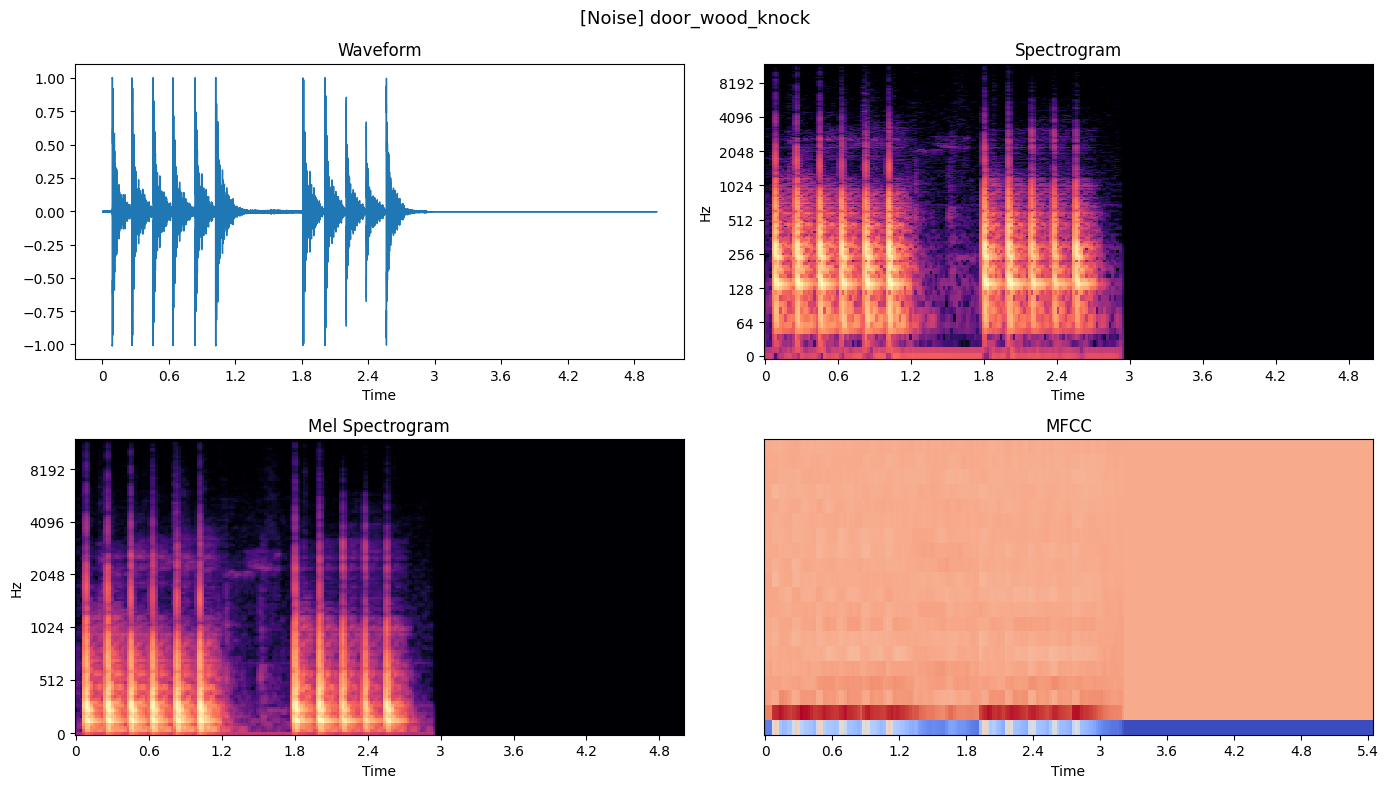

In [6]:
ESC50_DIR  = "/content/messy_mashup/ESC-50-master/audio"
ESC50_META = "/content/messy_mashup/ESC-50-master/meta/esc50.csv"

esc_meta = pd.read_csv(ESC50_META)
print(esc_meta.head())
print(f"\nTotal noise clips: {len(esc_meta)}")
print(f"Unique categories: {esc_meta['category'].nunique()}")
print(esc_meta['category'].value_counts())
# pick one clip per category and plot waveform + mel
for category in esc_meta['category'].unique()[:5]:  # first 5 categories
    row = esc_meta[esc_meta['category'] == category].iloc[0]
    path = os.path.join(ESC50_DIR, row['filename'])
    plot_audio(path, label=f"[Noise] {category}")

In [7]:
# printing dataset quality.
print("=" * 50)
print("QUALITY REPORT")
print("=" * 50)

print(f"\nTotal files:        {len(df)}")
print(f"  Stems:            {len(df[df.source == 'stem'])}")
print(f"  Mashups:          {len(df[df.source == 'mashup'])}")
print(f"  Noise:            {len(df[df.source == 'noise'])}")

print(f"\nLoad errors:        {df['path'].isna().sum() if 'error' in df.columns else 0}")
print(f"Silent files:       {df['is_silent'].sum()}")
print(f"Clipped files:      {df['is_clipped'].sum()}")
print(f"SR mismatch:        {(df['actual_sr'] != SR).sum()}")

# SR distribution across all sources
print(f"\nSample Rate Distribution:")
sr_counts = df['actual_sr'].value_counts().sort_index()
for sr_val, count in sr_counts.items():
    print(f"  {int(sr_val)} Hz — {count} files ({count/len(df)*100:.1f}%)")

print(f"\nSR stats per source:")
for source in ['stem', 'mashup', 'noise']:
    source_df = df[df.source == source]['actual_sr']
    if len(source_df):
        print(f"  {source:8s} — min={int(source_df.min())} max={int(source_df.max())} unique={sorted(source_df.unique().astype(int).tolist())}")

print(f"\nDuration (stems):")
stem_dur = df[df.source == 'stem']['duration']
print(f"  min={stem_dur.min():.2f}s  max={stem_dur.max():.2f}s  mean={stem_dur.mean():.2f}s")

print(f"\nDuration (mashups):")
mash_dur = df[df.source == 'mashup']['duration']
print(f"  min={mash_dur.min():.2f}s  max={mash_dur.max():.2f}s  mean={mash_dur.mean():.2f}s")

print(f"\nDuration (noise):")
noise_dur = df[df.source == 'noise']['duration']
print(f"  min={noise_dur.min():.2f}s  max={noise_dur.max():.2f}s  mean={noise_dur.mean():.2f}s")

# Problematic files count per genre
problems = df[df['is_silent'] | df['is_clipped'] | (df['actual_sr'] != SR)]
if len(problems):
    print(f"\nProblematic files per genre ({len(problems)} total):")
    print(problems.groupby('genre')['file'].count().to_string())
else:
    print("\nNo problematic files found.")

QUALITY REPORT

Total files:        9020
  Stems:            4000
  Mashups:          3020
  Noise:            2000

Load errors:        0
Silent files:       245
Clipped files:      3717
SR mismatch:        9020

Sample Rate Distribution:
  22050 Hz — 3020 files (33.5%)
  44100 Hz — 6000 files (66.5%)

SR stats per source:
  stem     — min=44100 max=44100 unique=[44100]
  mashup   — min=22050 max=22050 unique=[22050]
  noise    — min=44100 max=44100 unique=[44100]

Duration (stems):
  min=29.93s  max=30.65s  mean=30.02s

Duration (mashups):
  min=6.06s  max=30.58s  mean=28.65s

Duration (noise):
  min=5.00s  max=5.00s  mean=5.00s

Problematic files per genre (9020 total):
genre
airplane              40
blues                400
breathing             40
brushing_teeth        40
can_opening           40
car_horn              40
cat                   40
chainsaw              40
chirping_birds        40
church_bells          40
clapping              40
classical            400
clock_alarm 

- All three types of problems i.e silent files, clipped files and SR mismatch represent files where the audio data is either missing, distorted, or misaligned, and feeding them into a model without handling them first will quietly degrade performance without any obvious error.

### Handleing the problametic files
1. Silent files - drop them. There's no recoverable information.
2. Clipped files — depends on severity. Checking what fraction of samples are clipped
3. SR mismatch — resampling is enough as librosa.load  handles this for you automatically with the sr= parameter.

In [8]:
# 1. drop silent files
df = df[df['is_silent'] == False]

# 2. check clip severity and drop heavy clipping
def clip_fraction(path, sr=SR):
    y, _ = librosa.load(path, sr=sr)
    return np.mean(np.abs(y) >= 0.999)

df['clip_fraction'] = df['path'].apply(clip_fraction)
df = df[df['clip_fraction'] < 0.01]

# 3. SR mismatch — no action needed, librosa handles it on load

print(f"Clean files remaining: {len(df)}")
print(f"  Stems:   {len(df[df.source == 'stem'])}")
print(f"  Mashups: {len(df[df.source == 'mashup'])}")

Clean files remaining: 8727
  Stems:   3755
  Mashups: 3020


### Stem-level analysis

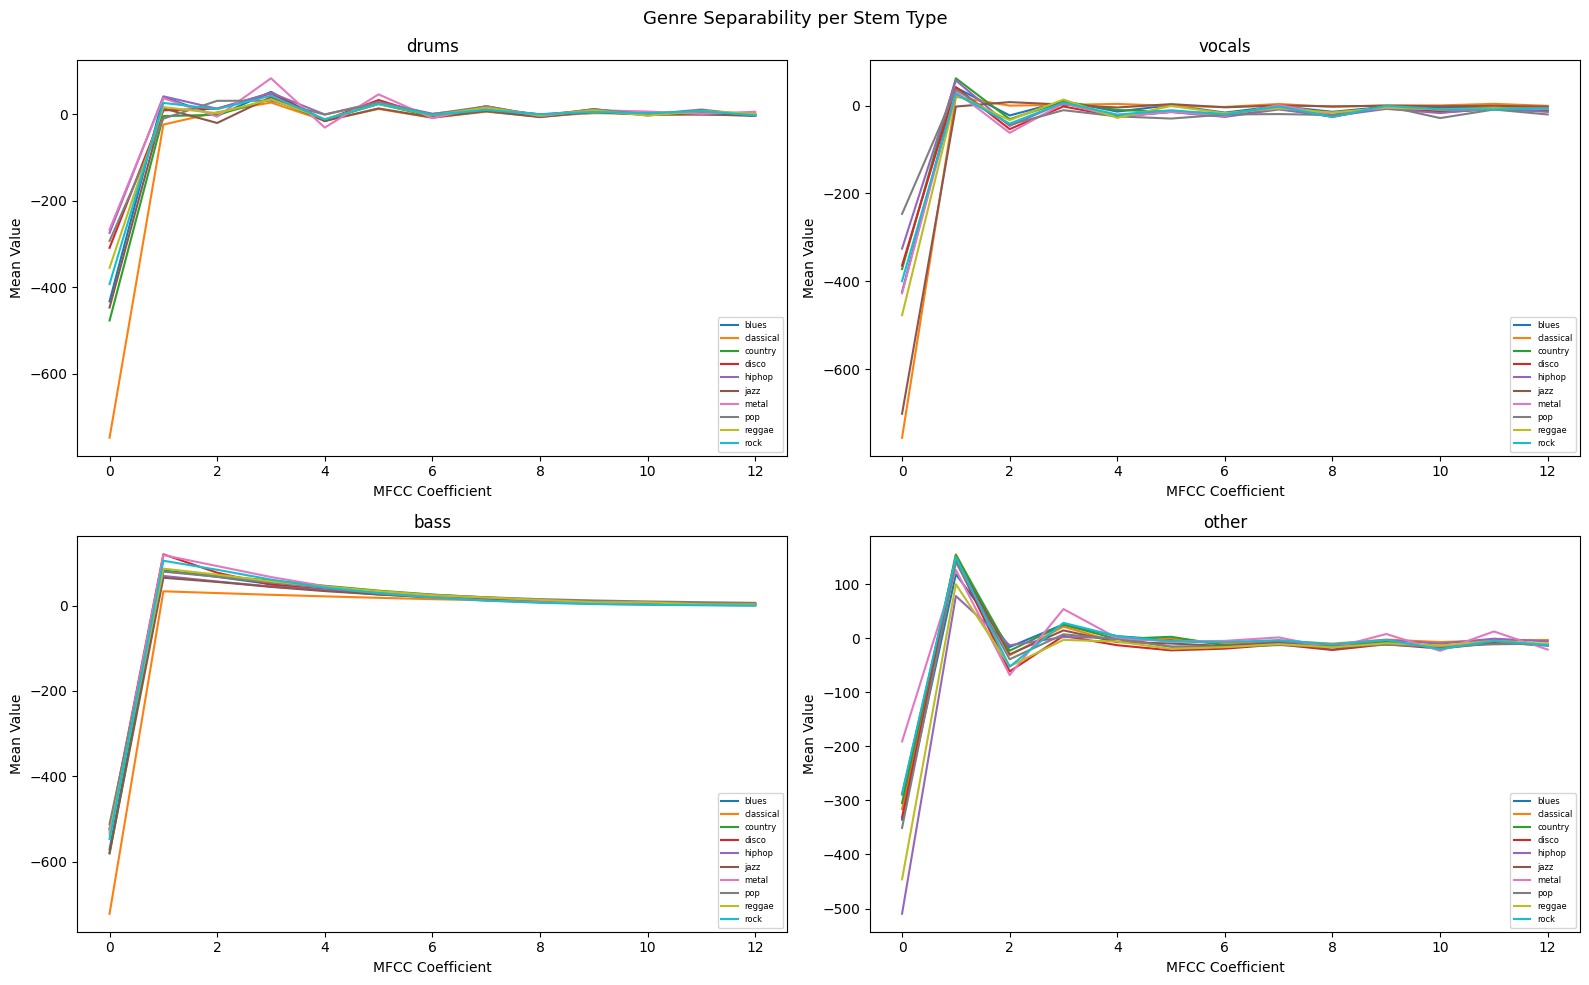

In [9]:
stem_types = ['drums', 'vocals', 'bass', 'other']
stem_mean_mfccs = {stem: {} for stem in stem_types}

for genre in df[df.source == 'stem']['genre'].unique():
    genre_df = df[(df.source == 'stem') & (df.genre == genre)]

    for stem in stem_types:
        # filter paths containing this stem name
        stem_paths = genre_df[genre_df['file'] == f'{stem}.wav']['path'].tolist()

        mfccs = []
        for path in stem_paths[:20]:
            y, _ = librosa.load(path, sr=SR)
            mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13).mean(axis=1)
            mfccs.append(mfcc)

        if mfccs:
            stem_mean_mfccs[stem][genre] = np.mean(mfccs, axis=0)

# plot separability per stem — one chart per stem
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Genre Separability per Stem Type", fontsize=13)

for ax, stem in zip(axes.flatten(), stem_types):
    for genre, mfcc_mean in stem_mean_mfccs[stem].items():
        ax.plot(mfcc_mean, label=genre)
    ax.set_title(f"{stem}")
    ax.set_xlabel("MFCC Coefficient")
    ax.set_ylabel("Mean Value")
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

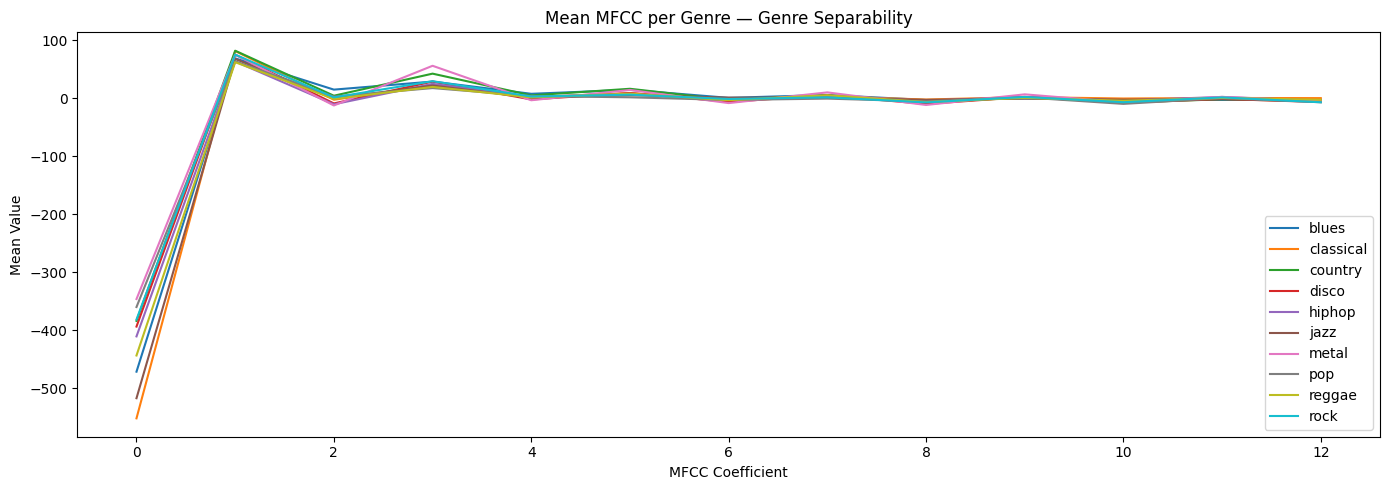

In [10]:
from PIL import Image
import io

genre_mean_mfccs = {}

for genre in df[df.source == 'stem']['genre'].unique():
    all_wavs = df[(df.source == 'stem') & (df.genre == genre)]['path'].tolist()

    mfccs = []
    for path in all_wavs[:20]:
        y, _ = librosa.load(path, sr=SR)
        mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13).mean(axis=1)
        mfccs.append(mfcc)
    genre_mean_mfccs[genre] = np.mean(mfccs, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
for genre, mfcc_mean in genre_mean_mfccs.items():
    ax.plot(mfcc_mean, label=genre)
ax.set_title("Mean MFCC per Genre — Genre Separability")
ax.set_xlabel("MFCC Coefficient")
ax.set_ylabel("Mean Value")
ax.legend()
plt.tight_layout()
plt.show()

- Each line in the above graph is a genre. If the lines are far apart from each other, the model(s) will find it easy to tell genres apart. If they're all bunched together, the genres sound similar and the model will struggle.
-  the stem where genre lines are most spread apart is the most discriminative. That stem should get more weight or attention in your model.

 ### Mashup vs clean stem comparison
 - if the mashup MFCC looks completely unrecognizable compared to the clean stem, your model needs heavy augmentation during training. If it still looks similar, simpler preprocessing may suffice

In [11]:
def get_representative_file(all_wavs, sr=SR, n_mfcc=13, mode="representative"):
    mfccs = []
    for path in all_wavs:
        y, _ = librosa.load(path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).mean(axis=1)
        mfccs.append(mfcc)
    mfccs = np.array(mfccs)
    mean = mfccs.mean(axis=0)
    distances = np.linalg.norm(mfccs - mean, axis=1)

    if mode == "representative":
        return all_wavs[np.argmin(distances)]   # closest to genre mean
    elif mode == "outlier":
        return all_wavs[np.argmax(distances)]   # furthest from genre mean

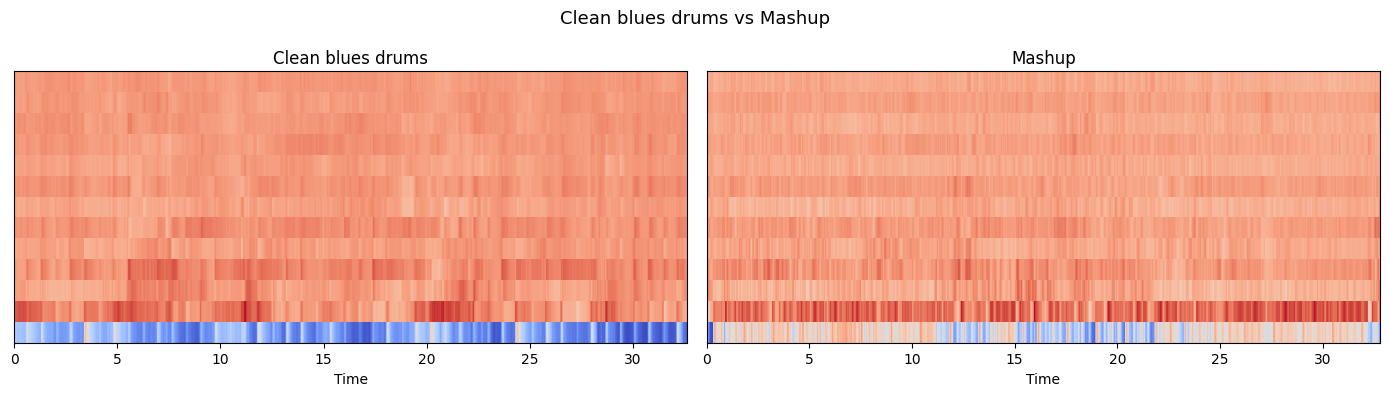

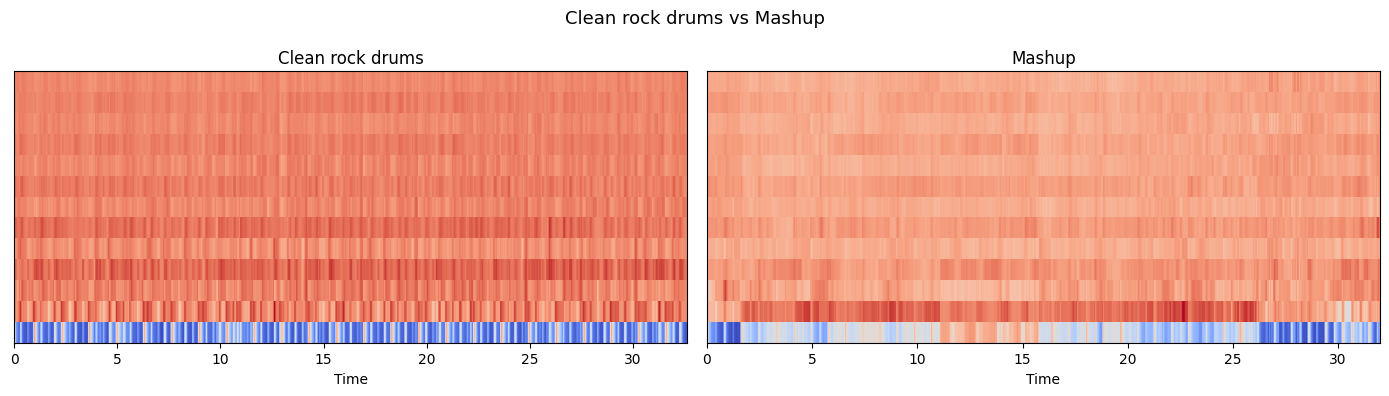

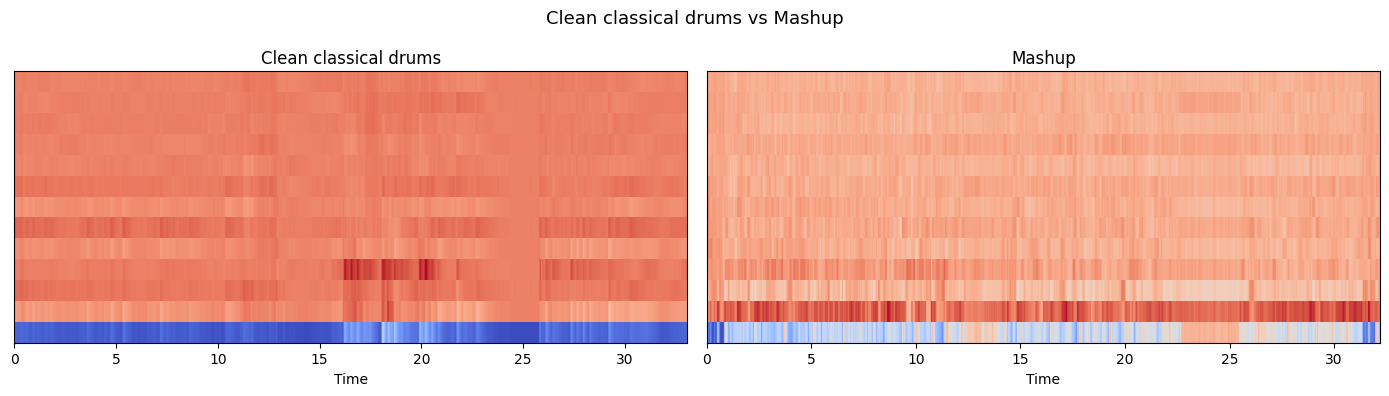

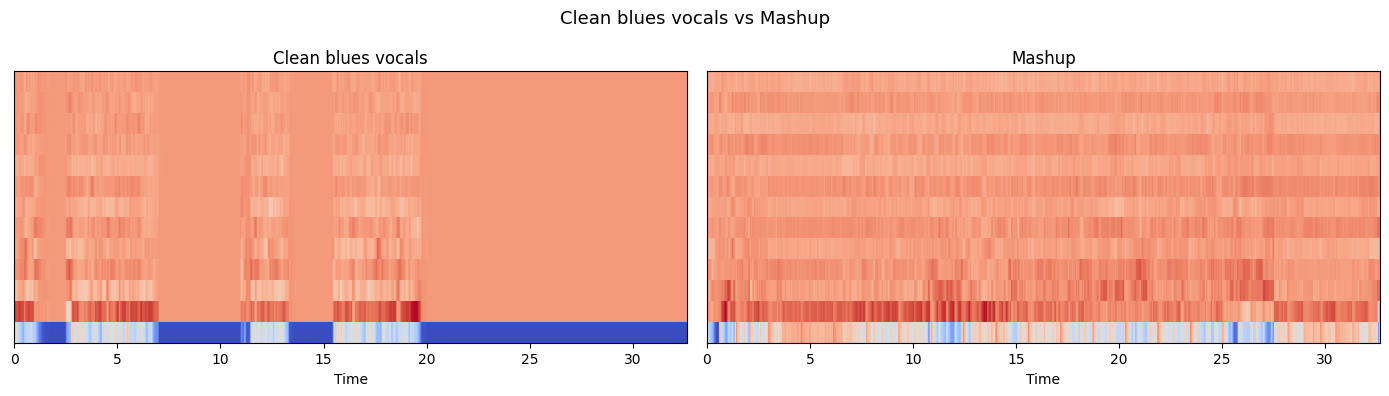

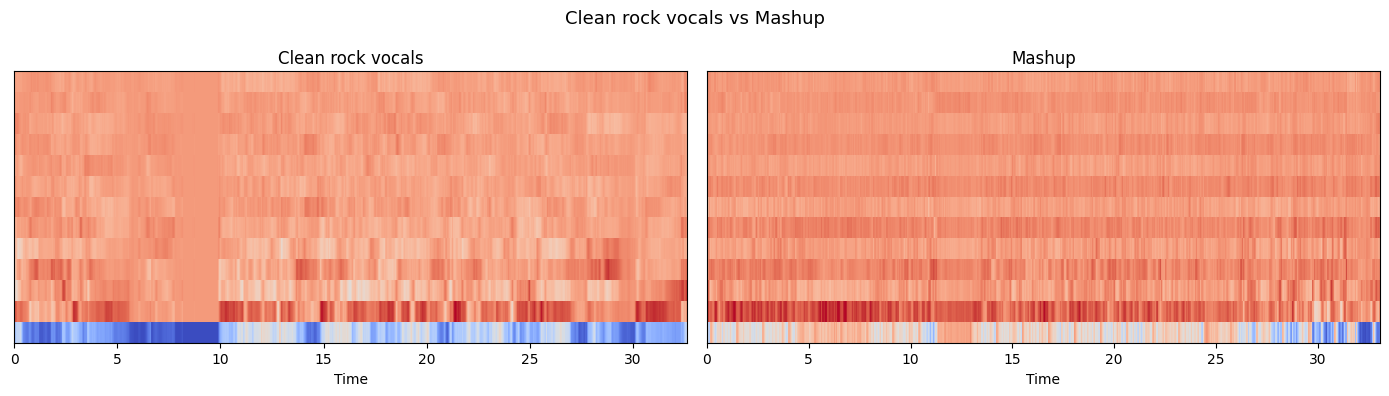

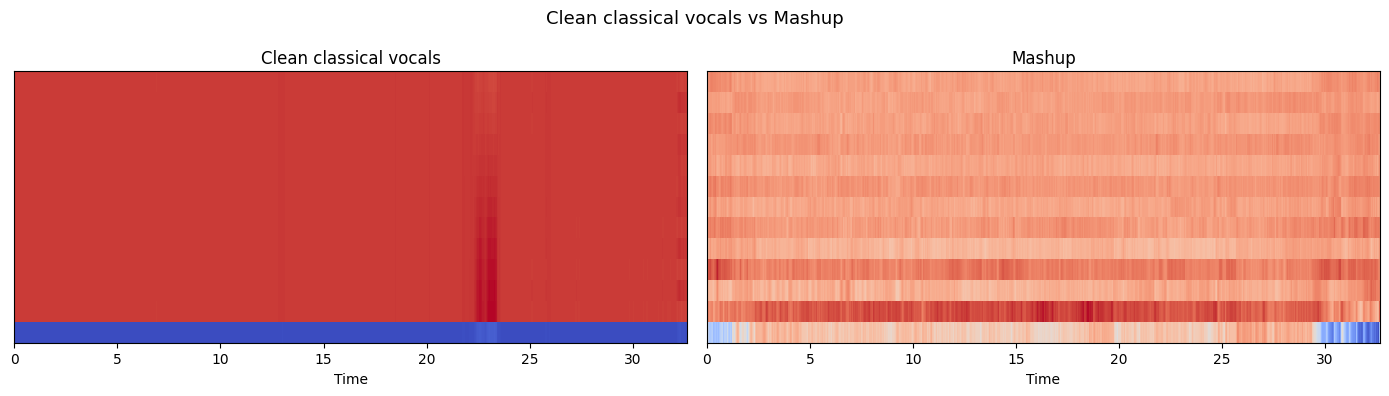

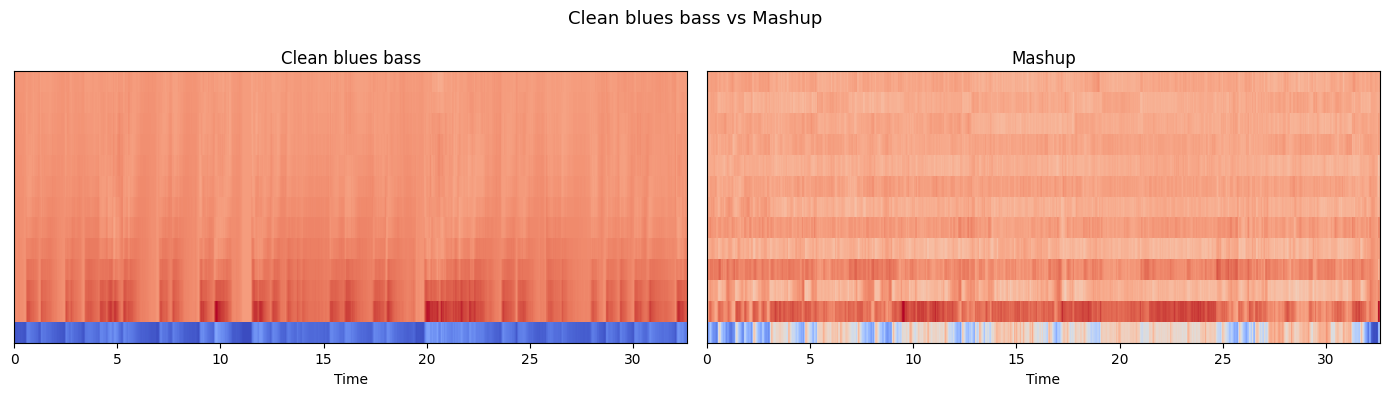

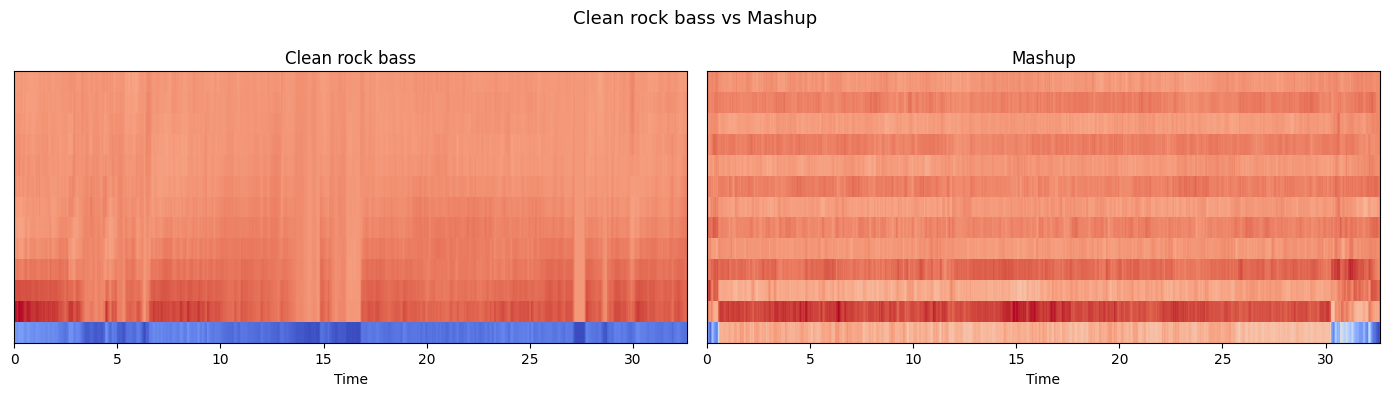

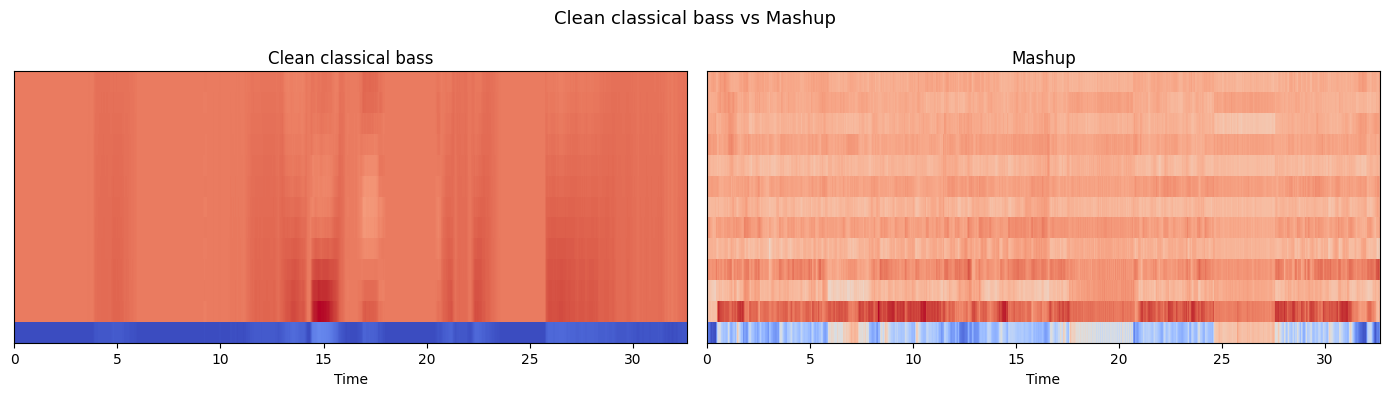

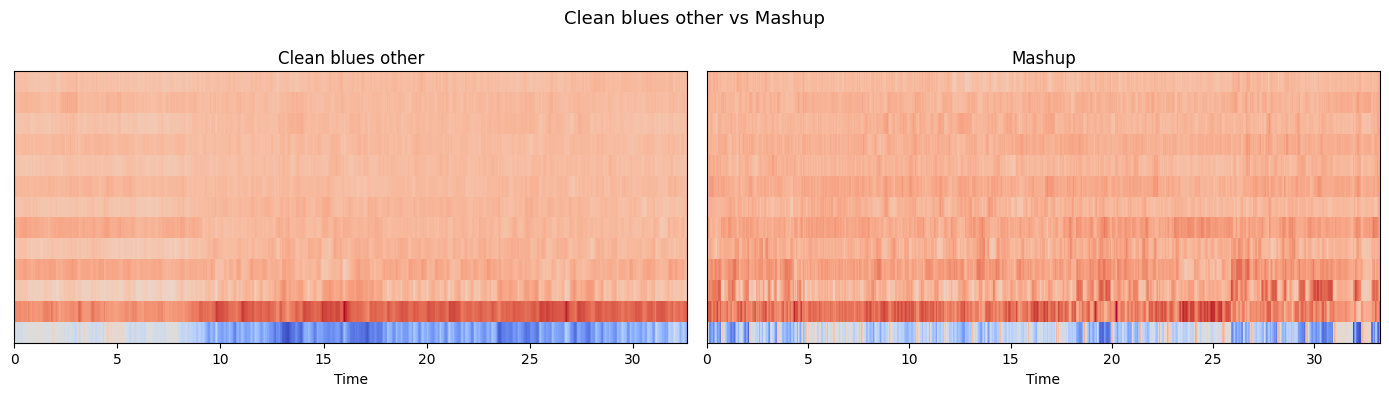

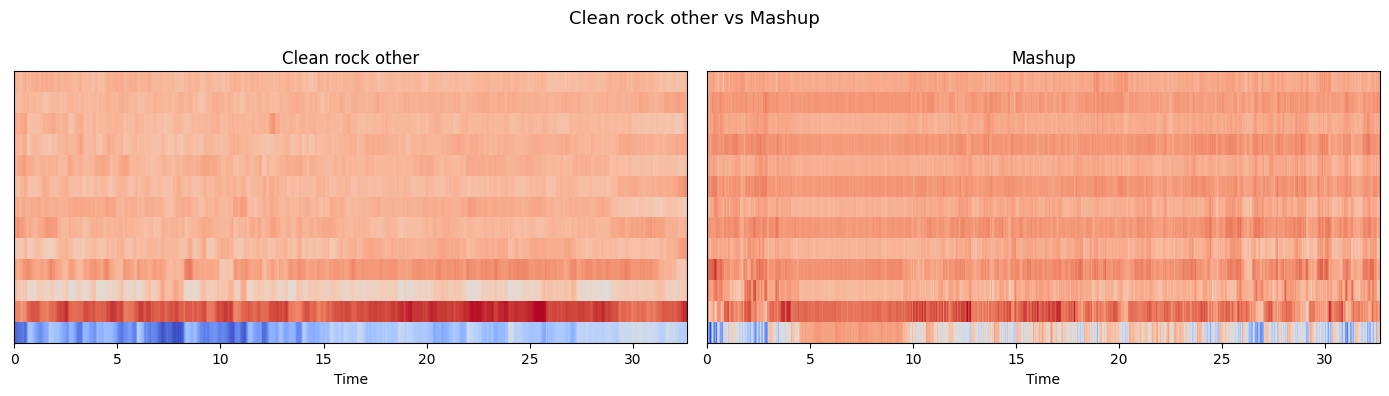

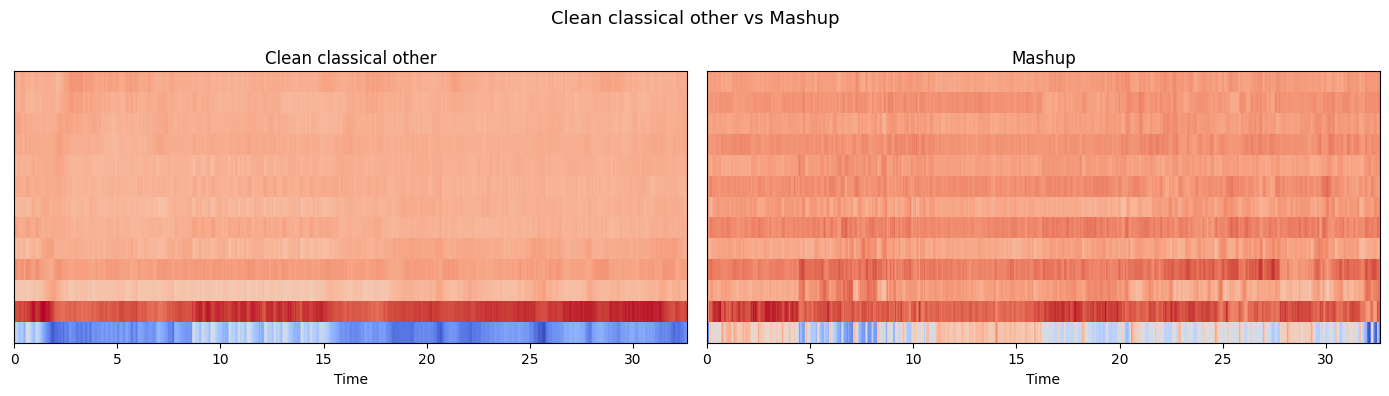

In [12]:
def compare_stem_vs_mashup(genre, stem='drums'):
    # get representative clean stem
    stem_paths = df[
        (df.source == 'stem') &
        (df.genre == genre) &
        (df.file == f'{stem}.wav')
    ]['path'].tolist()

    rep_path = get_representative_file(stem_paths, mode="representative")

    # pick a random mashup
    mashup_path = df[df.source == 'mashup'].sample(1)['path'].values[0]

    # plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Clean {genre} {stem} vs Mashup", fontsize=13)

    for ax, (label, path) in zip(axes, {f"Clean {genre} {stem}": rep_path, "Mashup": mashup_path}.items()):
        y, _ = librosa.load(path, sr=SR)
        mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13)
        librosa.display.specshow(mfcc, x_axis='time', ax=ax)
        ax.set_title(label)

    plt.tight_layout()
    plt.show()

for genre in ['blues', 'rock', 'classical']:
    compare_stem_vs_mashup(genre, stem='drums')
for genre in ['blues', 'rock', 'classical']:
    compare_stem_vs_mashup(genre, stem='vocals')
for genre in ['blues', 'rock', 'classical']:
    compare_stem_vs_mashup(genre, stem='bass')
for genre in ['blues', 'rock', 'classical']:
    compare_stem_vs_mashup(genre, stem='other')

- Representative file — the file whose MFCC vector is closest to the average MFCC of all files in that genre. Think of it as:

> "If I had to pick one blues song to show someone what blues sounds like as a genre, this is it."

- Outlier file — the file whose MFCC vector is furthest from that same average. Think of it as:

> "This blues song sounds the least like blues out of all 100 blues files."

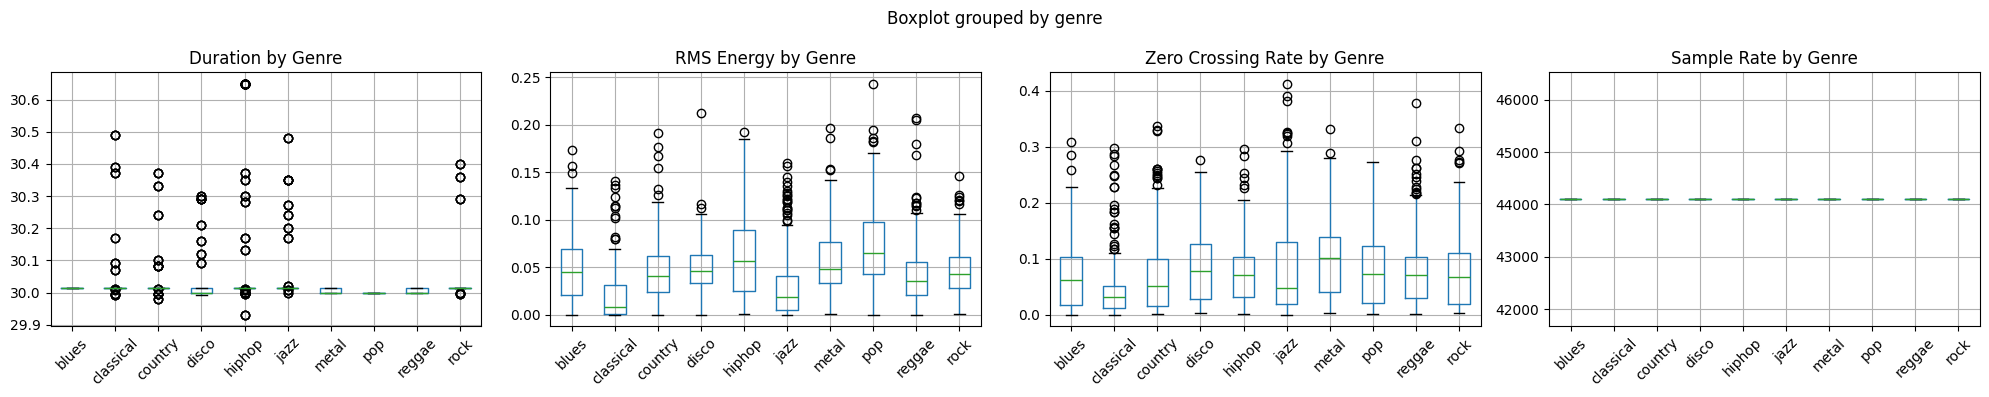

In [13]:
from PIL import Image
import io

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Data Quality Distributions", fontsize=13)

# Duration per genre
df[df.source == 'stem'].boxplot(column='duration', by='genre', ax=axes[0])
axes[0].set_title("Duration by Genre")
axes[0].set_xlabel("")
plt.sca(axes[0])
plt.xticks(rotation=45)

# RMS energy per genre
df[df.source == 'stem'].boxplot(column='rms', by='genre', ax=axes[1])
axes[1].set_title("RMS Energy by Genre")
axes[1].set_xlabel("")
plt.sca(axes[1])
plt.xticks(rotation=45)

# ZCR per genre
df[df.source == 'stem'].boxplot(column='zcr', by='genre', ax=axes[2])
axes[2].set_title("Zero Crossing Rate by Genre")
axes[2].set_xlabel("")
plt.sca(axes[2])
plt.xticks(rotation=45)

# SR per genre
df[df.source == 'stem'].boxplot(column='actual_sr', by='genre', ax=axes[3])
axes[3].set_title("Sample Rate by Genre")
axes[3].set_xlabel("")
plt.sca(axes[3])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Preprocessing (likely using a pretrained model for feature extraction and librosa and pytorch, for augmentation)
1. generating synthetic mashups
2. making an image out of it, via mel spectrogram, and feeding it into the pretrained model, and performing the classofication. (this did not perform well on submission, so trying AST)
3.

In [14]:
import os
import random
import numpy as np
import librosa
import soundfile as sf
import pandas as pd
from tqdm import tqdm

# Config
STEMS_DIR    = "/content/messy_mashup/genres_stems"
OUTPUT_DIR   = "/content/output_dir"
SR           = 16000
SEED         = 42
NUM_AUGMENTS = 7
TARGET_LEN   = int(28.5 * SR)  # match mean mashup duration from quality report

random.seed(SEED)
np.random.seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load noise paths from df
noise_paths = df[df.source == 'noise']['path'].tolist()
random.shuffle(noise_paths)


def tempo_sync(y, sr):
    """Slight random tempo stretch to simulate synchronization."""
    rate = random.uniform(0.85, 1.15)
    return librosa.effects.time_stretch(y, rate=rate)


def create_synthetic_mashup(genre_path, noise_paths, sr=SR, target_len=TARGET_LEN):
    stem_types    = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
    track_folders = [
        t for t in os.listdir(genre_path)
        if os.path.isdir(os.path.join(genre_path, t))
    ]

    if len(track_folders) < 2:
        return None

    # Pick a DIFFERENT random track for each stem (cross-song mixing)
    selected_tracks = random.choices(track_folders, k=len(stem_types))

    mixed = np.zeros(target_len, dtype=np.float32)

    for stem, track in zip(stem_types, selected_tracks):
        path = os.path.join(genre_path, track, stem)
        if not os.path.exists(path):
            continue

        y, _ = librosa.load(path, sr=sr)

        # Apply tempo stretch to simulate sync
        y = tempo_sync(y, sr)

        # Fit to target length
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        # Random per-stem volume scaling
        stem_gain = random.uniform(0.6, 1.0)
        mixed += stem_gain * y

    # Normalize before adding noise
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-9)

    # Add ONE OR MORE noise samples at random positions (matches actual mashup construction)
    num_noises = random.randint(1, 3)
    for _ in range(num_noises):
        noise_path = random.choice(noise_paths)
        noise, _   = librosa.load(noise_path, sr=sr)
        intensity  = random.uniform(0.05, 0.3)

        # Tile noise if shorter than target
        if len(noise) < target_len:
            repeats = int(np.ceil(target_len / len(noise)))
            noise   = np.tile(noise, repeats)

        # Random insert position
        max_start  = len(noise) - target_len
        start      = random.randint(0, max_start)
        noise_clip = noise[start: start + target_len]

        mixed = mixed + intensity * noise_clip

    # Final normalize
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-9)
    return mixed.astype(np.float32)


# Generate
records    = []
genres     = sorted([
    g for g in os.listdir(STEMS_DIR)
    if os.path.isdir(os.path.join(STEMS_DIR, g))
])
all_tracks = [
    (genre, track)
    for genre in genres
    for track in os.listdir(os.path.join(STEMS_DIR, genre))
    if os.path.isdir(os.path.join(STEMS_DIR, genre, track))
]

with tqdm(total=len(all_tracks) * NUM_AUGMENTS, desc="Generating mashups") as pbar:
    for genre in genres:
        genre_path    = os.path.join(STEMS_DIR, genre)
        track_folders = [
            t for t in os.listdir(genre_path)
            if os.path.isdir(os.path.join(genre_path, t))
        ]
        genre_dir = os.path.join(OUTPUT_DIR, genre)
        os.makedirs(genre_dir, exist_ok=True)

        for track in track_folders:
            for aug_idx in range(NUM_AUGMENTS):
                output_path = os.path.join(genre_dir, f"{track}_aug{aug_idx}_mashup.wav")

                y = create_synthetic_mashup(genre_path, noise_paths, sr=SR)
                if y is None:
                    print(f"  skipped {track} — not enough tracks in genre")
                    pbar.update(1)
                    continue

                sf.write(output_path, y, SR)
                records.append({
                    "path":    output_path,
                    "genre":   genre,
                    "track":   track,
                    "aug_idx": aug_idx,
                    "label":   genres.index(genre)
                })
                pbar.set_postfix(genre=genre, track=track, aug=aug_idx)
                pbar.update(1)

synth_df = pd.DataFrame(records)
print(f"\nGenerated {len(synth_df)} synthetic mashups")
print(synth_df['genre'].value_counts())

Generating mashups:  27%|██▋       | 1892/7000 [21:06<56:57,  1.49it/s, aug=1, genre=country, track=country.00034]


KeyboardInterrupt: 

## Dataset prepration

In [ ]:
from sklearn.model_selection import train_test_split

# split on unique tracks, not files
# this prevents aug0/aug1/aug2 of same track appearing in both train and val
tracks = synth_df[['genre', 'track']].drop_duplicates()

train_tracks, val_tracks = train_test_split(
    tracks,
    test_size=0.2,
    stratify=tracks['genre'],
    random_state=SEED
)

train_df = synth_df[synth_df['track'].isin(train_tracks['track'])].reset_index(drop=True)
val_df   = synth_df[synth_df['track'].isin(val_tracks['track'])].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print(f"Train tracks: {len(train_tracks)} | Val tracks: {len(val_tracks)}")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
from transformers import AutoFeatureExtractor

feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class MashupDataset(Dataset):
    def __init__(self, df, sr=16000, duration=10):
        self.df        = df.reset_index(drop=True)
        self.sr        = sr
        self.n_samples = sr * duration  # 160000

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load as numpy array (feature extractor expects numpy, not tensor)
        y, _ = librosa.load(row['path'], sr=self.sr, duration=10)

        # Pad or truncate to fixed length
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        # Normalize
        y = y / (np.max(np.abs(y)) + 1e-9)

        # AST feature extraction — handles mel spectrogram internally
        inputs = feature_extractor(
            y,
            sampling_rate=self.sr,
            return_tensors="pt",
            padding="max_length",
            max_length=1024,
            truncation=True
        )

        return {
            "input_values": inputs["input_values"].squeeze(0),  # (1024, 128)
            "labels": torch.tensor(row['label'], dtype=torch.long)
        }

In [ ]:
train_dataset = MashupDataset(train_df)
val_dataset   = MashupDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

## Model training, log on Wandb

### 1. pretrained model - efficientnet
- this did not perform well on submission v7 - 0.300
### trying AST now, and seeing how it performs

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import ASTForAudioClassification
from sklearn.metrics import f1_score, accuracy_score
import wandb

# Config
CFG = {
    "model_name":    "MIT/ast-finetuned-audioset-10-10-0.4593",
    "num_classes":   10,
    "epochs":        25,
    "freeze_epochs": 5,
    "lr_head":       1e-3,
    "lr_finetune":   1e-5,
    "batch_size":    8,   # reduced — AST is heavier than EfficientNet
    "device":        "cuda" if torch.cuda.is_available() else "cpu",
    "seed":          SEED,
    "accumulation_steps": 4  # effective batch size = 8 × 4 = 32
}

# Model
model = ASTForAudioClassification.from_pretrained(
    CFG["model_name"],
    num_labels=CFG["num_classes"],
    ignore_mismatched_sizes=True
)
model = model.to(CFG["device"])

# Freeze everything except classification head
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

def unfreeze_all(model, lr_backbone=1e-5, lr_head=1e-4):
    # Unfreeze in groups with different LRs
    optimizer.param_groups.clear()

    # Last 2 encoder layers + classifier only
    head_params     = [p for n, p in model.named_parameters() if "classifier" in n]
    encoder_params  = [p for n, p in model.named_parameters() if any(k in n for k in ["encoder.layer.11", "encoder.layer.10"])]

    optimizer.add_param_group({"params": head_params,    "lr": lr_head})
    optimizer.add_param_group({"params": encoder_params, "lr": lr_backbone})

freeze_backbone(model)

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_head"]
)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, accumulation_steps=4):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        input_values = batch["input_values"].to(device)
        labels       = batch["labels"].to(device)

        outputs = model(input_values=input_values)
        logits  = outputs.logits
        loss    = criterion(logits, labels) / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps  # unscale for logging
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # handle leftover batches if len(loader) not divisible by accumulation_steps
    if (i + 1) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_values = batch["input_values"].to(device)
            labels       = batch["labels"].to(device)

            outputs = model(input_values=input_values)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1

### Traning loop

In [ ]:
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")

wandb.init(
    project = os.environ["WANDB_PROJECT"],
    entity  = os.environ["WANDB_ENTITY"],
    name    = "1_pretrained_ast",
    config  = CFG
)
wandb.watch(model, log="gradients", log_freq=50)

best_val_acc = 0.0

for epoch in tqdm(range(1, CFG["epochs"] + 1), desc="Epochs"):
    if epoch == CFG["freeze_epochs"] + 1:
        print(f"\nEpoch {epoch}: unfreezing backbone, switching to lr={CFG['lr_finetune']}")
        torch.cuda.empty_cache()
        unfreeze_all(model)
        for pg in optimizer.param_groups:
            pg['lr'] = CFG["lr_finetune"]
        train_loader     = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
        accumulation_steps = 8

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, CFG["device"])
    val_loss,   val_acc,   val_f1   = eval_one_epoch(model, val_loader,   criterion, CFG["device"])

    scheduler.step(val_loss)

    wandb.log({
        "epoch":      epoch,
        "train/loss": train_loss,
        "train/acc":  train_acc,
        "train/f1":   train_f1,
        "val/loss":   val_loss,
        "val/acc":    val_acc,
        "val/f1":     val_f1,
        "lr":         optimizer.param_groups[0]['lr'],
        "frozen":     epoch <= CFG["freeze_epochs"]
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "//content/working/best_ast.pt")
        wandb.save("/content/working/best_ast.pt")
        tqdm.write(f"  ✓ saved best model (val_acc={val_acc:.4f})")

    tqdm.write(f"Epoch {epoch:02d} | "
               f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
               f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")
wandb.finish()

## Model testing and prediction for the pertrained model

In [ ]:
import os
import torch
import librosa
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import ASTForAudioClassification, AutoFeatureExtractor
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Label mapping (same as training) ───────────────────────────────
genres       = sorted([g for g in os.listdir(STEMS_DIR) if os.path.isdir(os.path.join(STEMS_DIR, g))])
idx_to_genre = {idx: genre for idx, genre in enumerate(genres)}
print(idx_to_genre)

# ── Feature extractor ───────────────────────────────────────────────
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

# ── Test Dataset ────────────────────────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, base_dir, test_csv, sr=16000, duration=10):
        self.base_dir  = base_dir
        self.test_df   = pd.read_csv(test_csv)
        self.sr        = sr
        self.n_samples = sr * duration

    def __len__(self):
        return len(self.test_df)

    def __getitem__(self, idx):
        filename = self.test_df.iloc[idx]["filename"]
        path     = os.path.join(self.base_dir, filename)

        # Load as numpy
        y, _ = librosa.load(path, sr=self.sr, duration=10)

        # Pad or truncate
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        # Normalize
        y = y / (np.max(np.abs(y)) + 1e-9)

        # AST feature extraction
        inputs = feature_extractor(
            y,
            sampling_rate=self.sr,
            return_tensors="pt",
            padding="max_length",
            max_length=1024,
            truncation=True
        )

        return inputs["input_values"].squeeze(0)

# ── Dataloader ──────────────────────────────────────────────────────
BASE_DIR = "/content/messy_mashup"
TEST_CSV = "/content/messy_mashup/test.csv"

test_dataset = TestDataset(base_dir=BASE_DIR, test_csv=TEST_CSV)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test batches: {len(test_loader)}")

# ── Load best model ─────────────────────────────────────────────────
model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load("/content/working/best_ast.pt"))
model = model.to(CFG["device"])
model.eval()

# ── Predict ─────────────────────────────────────────────────────────
pred_indices = []

with torch.no_grad():
    for input_values in tqdm(test_loader, desc="Predicting"):
        input_values = input_values.to(CFG["device"])
        outputs      = model(input_values=input_values)
        preds        = outputs.logits.argmax(1)
        pred_indices.extend(preds.cpu().numpy())

pred_genres = [idx_to_genre[i] for i in pred_indices]

# ── Build submission ─────────────────────────────────────────────────
test_df    = pd.read_csv(TEST_CSV)
submission = pd.DataFrame({
    "id":    test_df["id"],
    "label": pred_genres
})
submission = submission.sort_values("id").reset_index(drop=True)

# ── Sanity check ─────────────────────────────────────────────────────
sample = pd.read_csv("/content/messy_mashup/sample_submission.csv")
print(f"\nSample submission columns: {sample.columns.tolist()}")
print(f"Your submission columns:   {submission.columns.tolist()}")
print(f"\nSample rows: {len(sample)} | Your rows: {len(submission)}")
print(f"\nLabel distribution:\n{submission['label'].value_counts()}")
print(f"\nFirst 10 predictions:\n{submission.head(10)}")

# ── Save ─────────────────────────────────────────────────────────────
submission.to_csv("/content/working/submission.csv", index=False)
print("\nSaved to /content/working/submission.csv")

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=GENRES,
            yticklabels=GENRES,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Preprocessing from milestone 4

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import os
import torch
import torch
import numpy as np
import random
import torchaudio
import os
import glob
from pathlib import Path
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

def extract_and_save_features(input_dir, output_dir, target_sr=22050):
    """Converts audio to Mel-spectrograms in dB and saves as PyTorch tensors."""
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=target_sr, n_fft=2048, hop_length=512, n_mels=128
    )
    amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    # Find all .wav files in the input directory
    wav_files = glob.glob(os.path.join(input_dir, '**', '*.wav'), recursive=True)
    
    if not wav_files:
        print(f"Warning: No .wav files found in {input_dir}")
        return

    for wav_path in wav_files:
        # Replicate directory structure
        rel_path = os.path.relpath(wav_path, input_dir)
        out_path = Path(output_dir) / rel_path
        out_path = out_path.with_suffix('.pt')
        
        # Ensure the target directory exists in /kaggle/working/
        out_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Process and save
        waveform, sr = torchaudio.load(wav_path)
        mel_spec = mel_transform(waveform)
        mel_spec_db = amplitude_to_db(mel_spec)
        
        torch.save(mel_spec_db, out_path)
    
    print(f"Successfully saved {len(wav_files)} feature files to {output_dir}")
INPUT_DIR = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups'
OUTPUT_DIR = '/kaggle/working/features/train/'

extract_and_save_features(INPUT_DIR, OUTPUT_DIR)

# making for test set as well.


import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import os
import torch
import torch
import numpy as np
import random
import torchaudio
import os
import glob
from pathlib import Path
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report


## reading the test file, and then reading the songs from it and creating a folder val and then create the val_dataset

import os
import shutil
import pandas as pd

csv_path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv"
source_root = "/kaggle/working/features/train"
val_root = "/kaggle/working/features/val"

df = pd.read_csv(csv_path)

os.makedirs(val_root, exist_ok=True)

for file in df["filename"]:   
    for root, _, files in os.walk(source_root):
        if file in files:
            src = os.path.join(root, file)

            genre = os.path.basename(root)
            dst_dir = os.path.join(val_root, genre)
            os.makedirs(dst_dir, exist_ok=True)

            shutil.move(src, os.path.join(dst_dir, file))

## Model training and dataset prepration

import os
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader

class MashupDataset(Dataset):
    def __init__(self, feature_dir):
        self.files = []
        self.labels = []

        self.genres = sorted(os.listdir(feature_dir))
        self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}

        for genre in self.genres:
            genre_path = os.path.join(feature_dir, genre)

            for root, _, files in os.walk(genre_path):
                for f in files:
                    if f.endswith(".pt"):
                        self.files.append(os.path.join(root, f))
                        self.labels.append(self.genre_to_idx[genre])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = torch.load(self.files[idx])   # load precomputed mel
        label = self.labels[idx]

        if mel.dim() == 3:      # (1, mel, time)
            mel = mel

        return mel, label

class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # RNN
        self.lstm = nn.LSTM(
            input_size=64*32,   # channels * freq after pooling
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )

        # classifier
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)                    # (B,64,F,T)
        print("Q4:", x.shape)
        B, C, F, T = x.shape
        x = x.permute(0,3,1,2)             # (B,T,C,F)
        x = x.reshape(B, T, C*F)           # (B,T,features)

        x,_ = self.lstm(x)                 # (B,T,128)

        x = torch.max(x, dim=1).values     # global max pool

        return self.fc(x)

# Training Loop
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):

    for epoch in range(num_epochs):
        model.train()
        total, correct = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            if x.dim() == 3:
                x = x.unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_acc = correct / total
        print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f}")
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        print(f"Epoch {e+1}, Acc: {correct/total:.4f}")

train_dataset = MashupDataset("/kaggle/working/features/train/")
print(len(train_dataset))

train_dataset = MashupDataset("/kaggle/working/features/train/")
val_dataset   = MashupDataset("/kaggle/working/features/val/")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = CRNN(num_classes=10)
lstm_params = sum(p.numel() for p in model.lstm.parameters() if p.requires_grad)
print("Q5: ",lstm_params)
train(model, loader)